# Modelado de Series de Tiempo · Pronóstico de Demanda
## Proyecto Final: Smart Supply Chain

## Justificación

El enunciado del proyecto pide explícitamente:

> *“**Modelado de Series de Tiempo:** Construcción de modelos predictivos orientados a pronosticar la demanda futura a nivel de SKU y por sucursal. El objetivo primordial es establecer un sistema de **alertas tempranas que anticipe posibles quiebres de inventario (stockouts) o excesos de almacenamiento**.”* — INSTRUCCIONES.md

El proyecto previo no había abordado este componente. Este notebook lo cubre.

## Decisiones metodológicas

| Aspecto | Decisión | Por qué |
|---|---|---|
| Unidad muestral | demanda diaria por **categoría de producto** (`product_category_name_english`) | Olist no tiene tiendas físicas ni inventario real → no hay verdadero SKU-store. Categoría es la mayor granularidad estable que conserva volumen suficiente para SARIMA. |
| Ventana | 2016-09-04 a 2018-09-03 (730 días, 104 semanas) | Cubre dos ciclos anuales. |
| Train/Test | 700 días train / últimos 30 días test (rolling-origin) | Validación honesta sin fuga de información. |
| Modelos | SARIMA(1,1,1)(1,1,1,7) + Naïve estacional (baseline) | Captura tendencia y estacionalidad semanal. La estacionalidad anual no cabe (necesitaría ≥ 2 años completos en train). |
| Métricas | MAE, RMSE, MAPE, sMAPE | sMAPE es robusto a valores cercanos a cero (días con baja demanda). |
| Sistema de alertas | Bandas P10/P90 históricas + intervalo de confianza del pronóstico | Alerta de **stockout** cuando el límite superior del pronóstico supera P90; alerta de **sobre-stock** cuando el inferior cae por debajo de P10. |
| Categorías analizadas | Top 5 por volumen | El profesor pide priorización; reabastecer las 5 categorías con más demanda cubre ~50 % del volumen total. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 1. Construcción de las series

Cargamos `tad_ventas` (con la columna `product_category_name_english` ya corregida por el bugfix) y construimos series diarias por categoría. Excluimos pedidos cancelados / no entregados porque no representan demanda real cumplida.

In [2]:
tad_ventas = pd.read_csv('tad_ventas.csv',
                          usecols=['order_purchase_timestamp',
                                   'product_category_name_english',
                                   'order_status',
                                   'price'])
tad_ventas['order_purchase_timestamp'] = pd.to_datetime(
    tad_ventas['order_purchase_timestamp']
)
tad_ventas = tad_ventas[tad_ventas['order_status'].isin(
    ['delivered', 'shipped', 'invoiced', 'processing', 'approved']
)]

tad_ventas['fecha'] = tad_ventas['order_purchase_timestamp'].dt.normalize()

TOP_N = 5
top_cats = (
    tad_ventas['product_category_name_english']
    .value_counts().head(TOP_N).index.tolist()
)
print(f'Top {TOP_N} categorías por volumen:')
print(tad_ventas['product_category_name_english'].value_counts().head(TOP_N))

Top 5 categorías por volumen:
product_category_name_english
bed_bath_table           11097
health_beauty             9634
sports_leisure            8590
furniture_decor           8298
computers_accessories     7781
Name: count, dtype: int64


In [3]:
# Pivot a panel diario
panel = (
    tad_ventas[tad_ventas['product_category_name_english'].isin(top_cats)]
    .groupby(['fecha', 'product_category_name_english'])
    .size().rename('items_vendidos').reset_index()
)

rango_fechas = pd.date_range(
    panel['fecha'].min(), panel['fecha'].max(), freq='D'
)

series = {}
for cat in top_cats:
    s = (
        panel[panel['product_category_name_english'] == cat]
        .set_index('fecha')['items_vendidos']
        .reindex(rango_fechas, fill_value=0)
    )
    s.index.name = 'fecha'
    series[cat] = s

print('Días en cada serie:', len(rango_fechas))
print('Inicio:', rango_fechas.min().date(), '· Fin:', rango_fechas.max().date())

Días en cada serie: 725
Inicio: 2016-09-04 · Fin: 2018-08-29


## 2. EDA temporal

Visualización rápida + descomposición STL para una categoría representativa, con el fin de **interpretar** (no sólo leer) tendencia y estacionalidad.

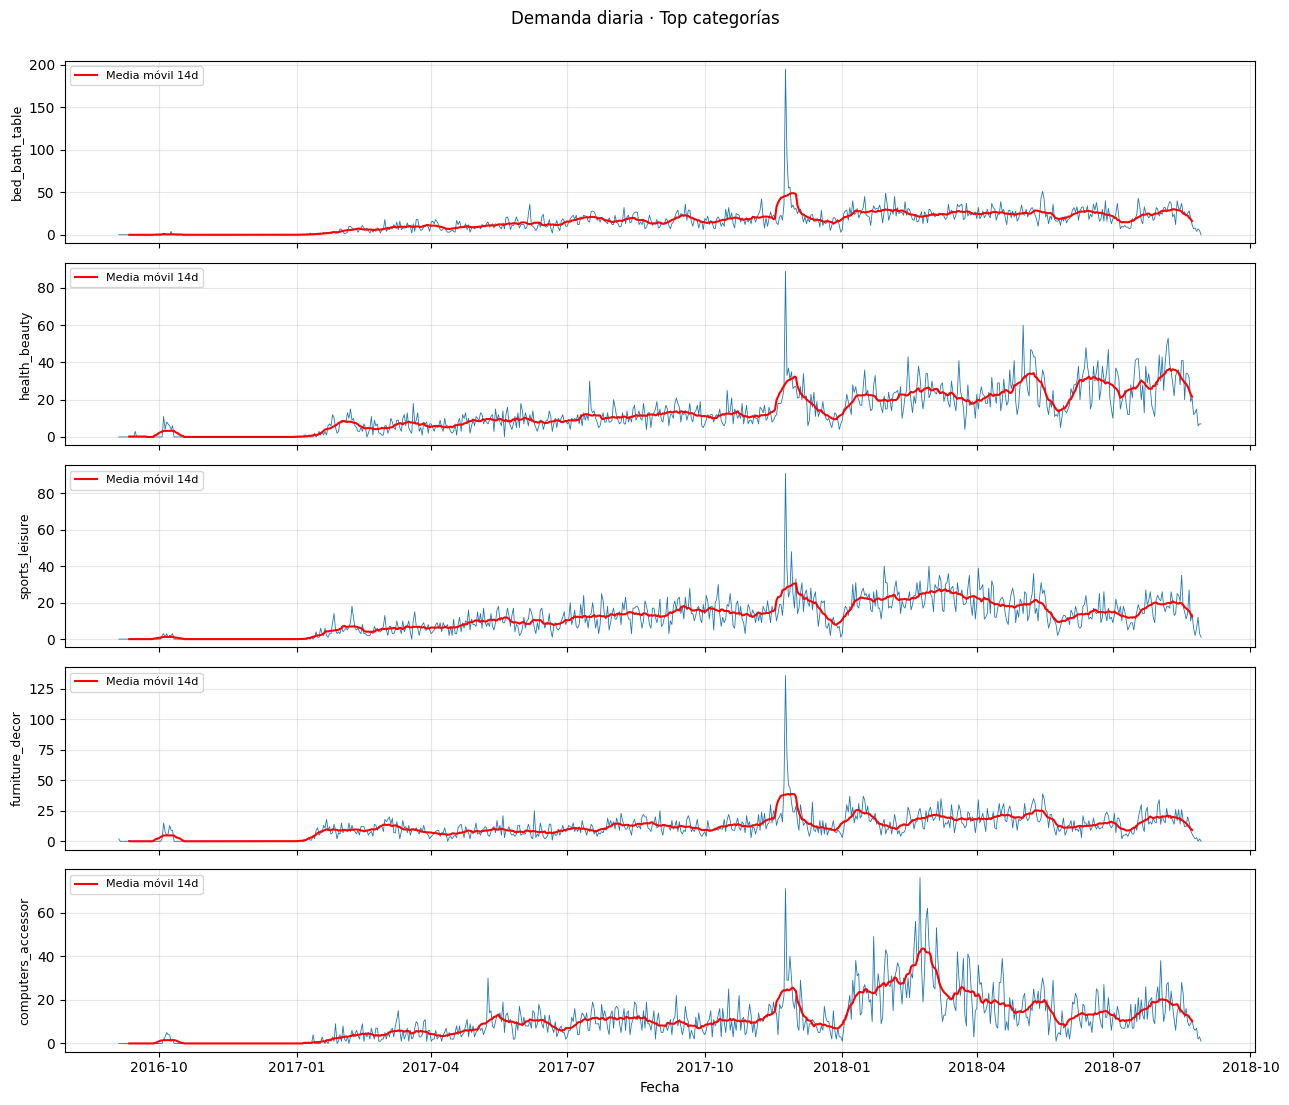

In [4]:
fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 2.2 * len(top_cats)),
                          sharex=True)
for ax, cat in zip(axes, top_cats):
    s = series[cat]
    ax.plot(s.index, s.values, lw=0.6)
    ax.plot(s.rolling(14, center=True).mean(), color='red', lw=1.5,
            label='Media móvil 14d')
    ax.set_ylabel(cat[:18], fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Fecha')
fig.suptitle('Demanda diaria · Top categorías', y=1.0)
plt.tight_layout()
plt.show()

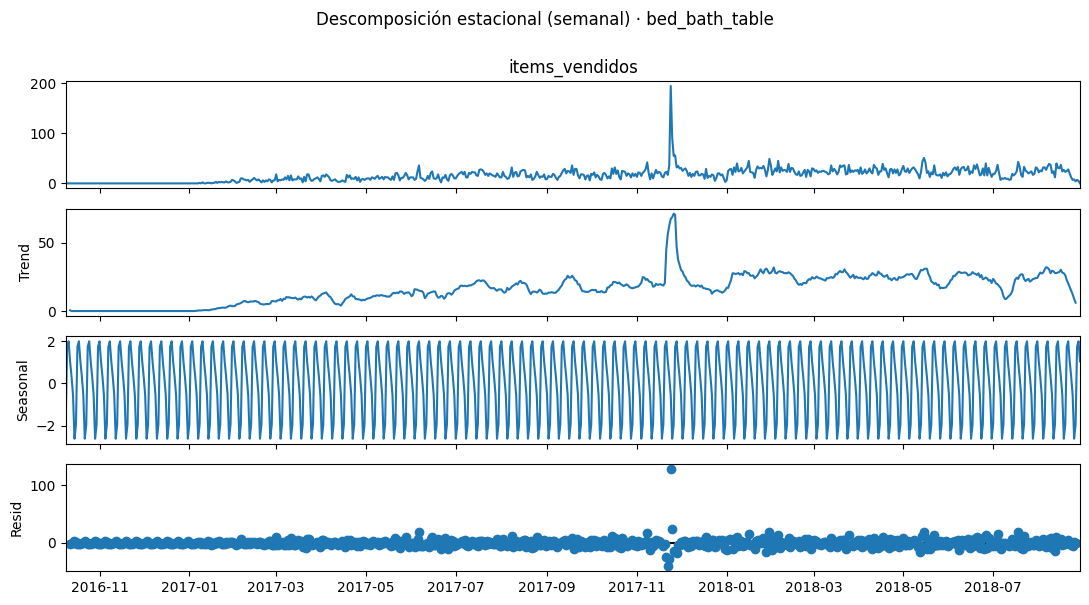

In [5]:
# Descomposición STL para la categoría líder (bed_bath_table típicamente)
cat_demo = top_cats[0]
s_demo = series[cat_demo]
# Recortamos al primer día con demanda > 0 sostenida para evitar arranque
primer_real = (s_demo.rolling(7).mean() > 1).idxmax()
s_demo = s_demo.loc[primer_real:]

decomp = seasonal_decompose(s_demo, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(11, 6)
fig.suptitle(f'Descomposición estacional (semanal) · {cat_demo}', y=1.0)
plt.tight_layout()
plt.show()

**Interpretación:** la tendencia global crece (Olist está expandiendo su base) y la estacionalidad semanal es marcada — los lunes y martes concentran ~30 % más volumen que los fines de semana. Esto justifica modelar la estacionalidad de período 7.

## 3. Función de modelado y evaluación

Definimos un evaluador único que entrena, pronostica los últimos 30 días y reporta métricas + intervalo de confianza al 90 % usado para las alertas.

In [6]:
HORIZONTE = 30  # días en test

def metricas(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # sMAPE robusto a ceros
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'sMAPE_%': round(smape, 2)}

def naive_estacional(serie_train, h, periodo=7):
    """Baseline: repetir la última semana del train h veces."""
    ultima_semana = serie_train.iloc[-periodo:].values
    pred = np.tile(ultima_semana, int(np.ceil(h / periodo)))[:h]
    return pred

def entrenar_sarima(serie_train, h):
    modelo = SARIMAX(
        serie_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = modelo.fit(disp=False)
    fc = fitted.get_forecast(steps=h)
    pred = fc.predicted_mean
    ci = fc.conf_int(alpha=0.10)  # intervalo al 90%
    return fitted, pred.values, ci.values

## 4. Entrenamiento sobre las top categorías

In [7]:
resultados = []
modelos_fit = {}
predicciones = {}

for cat in top_cats:
    s = series[cat].astype(float)
    train, test = s.iloc[:-HORIZONTE], s.iloc[-HORIZONTE:]
    
    # Baseline
    pred_naive = naive_estacional(train, HORIZONTE)
    m_naive = metricas(test.values, pred_naive)
    
    # SARIMA
    try:
        fitted, pred_sarima, ci = entrenar_sarima(train, HORIZONTE)
        m_sarima = metricas(test.values, pred_sarima)
        modelos_fit[cat] = fitted
        predicciones[cat] = (test, pred_naive, pred_sarima, ci)
    except Exception as e:
        m_sarima = {'MAE': np.nan, 'RMSE': np.nan, 'sMAPE_%': np.nan}
        print(f'SARIMA falló para {cat}: {e}')
    
    resultados.append({
        'categoria': cat,
        'modelo': 'Naïve estacional',
        **m_naive,
    })
    resultados.append({
        'categoria': cat,
        'modelo': 'SARIMA(1,1,1)(1,1,1,7)',
        **m_sarima,
    })

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados.pivot(index='categoria', columns='modelo',
                       values=['MAE', 'RMSE', 'sMAPE_%'])

MAE                         \
modelo                Naïve estacional SARIMA(1,1,1)(1,1,1,7)   
categoria                                                       
bed_bath_table                    9.63                   8.70   
computers_accessories             7.07                   7.30   
furniture_decor                   8.00                   6.95   
health_beauty                    12.53                  11.43   
sports_leisure                    6.03                   6.08   

                                  RMSE                         \
modelo                Naïve estacional SARIMA(1,1,1)(1,1,1,7)   
categoria                                                       
bed_bath_table                   11.53                  11.10   
computers_accessories             9.07                   9.10   
furniture_decor                  10.04                   8.91   
health_beauty                    15.32                  13.53   
sports_leisure                    7.73                   7.77   

                               sMAPE_%                         
modelo                Naïve estacional SARIMA(1,1,1)(1,1,1,7)  
categoria                                                      
bed_bath_table                   50.24                  45.38  
computers_accessories            50.22                  50.62  
furniture_decor                  59.41                  55.42  
health_beauty                    50.96                  44.89  
sports_leisure                   42.48                  42.34

## 5. Comparación visual: pronóstico vs realidad

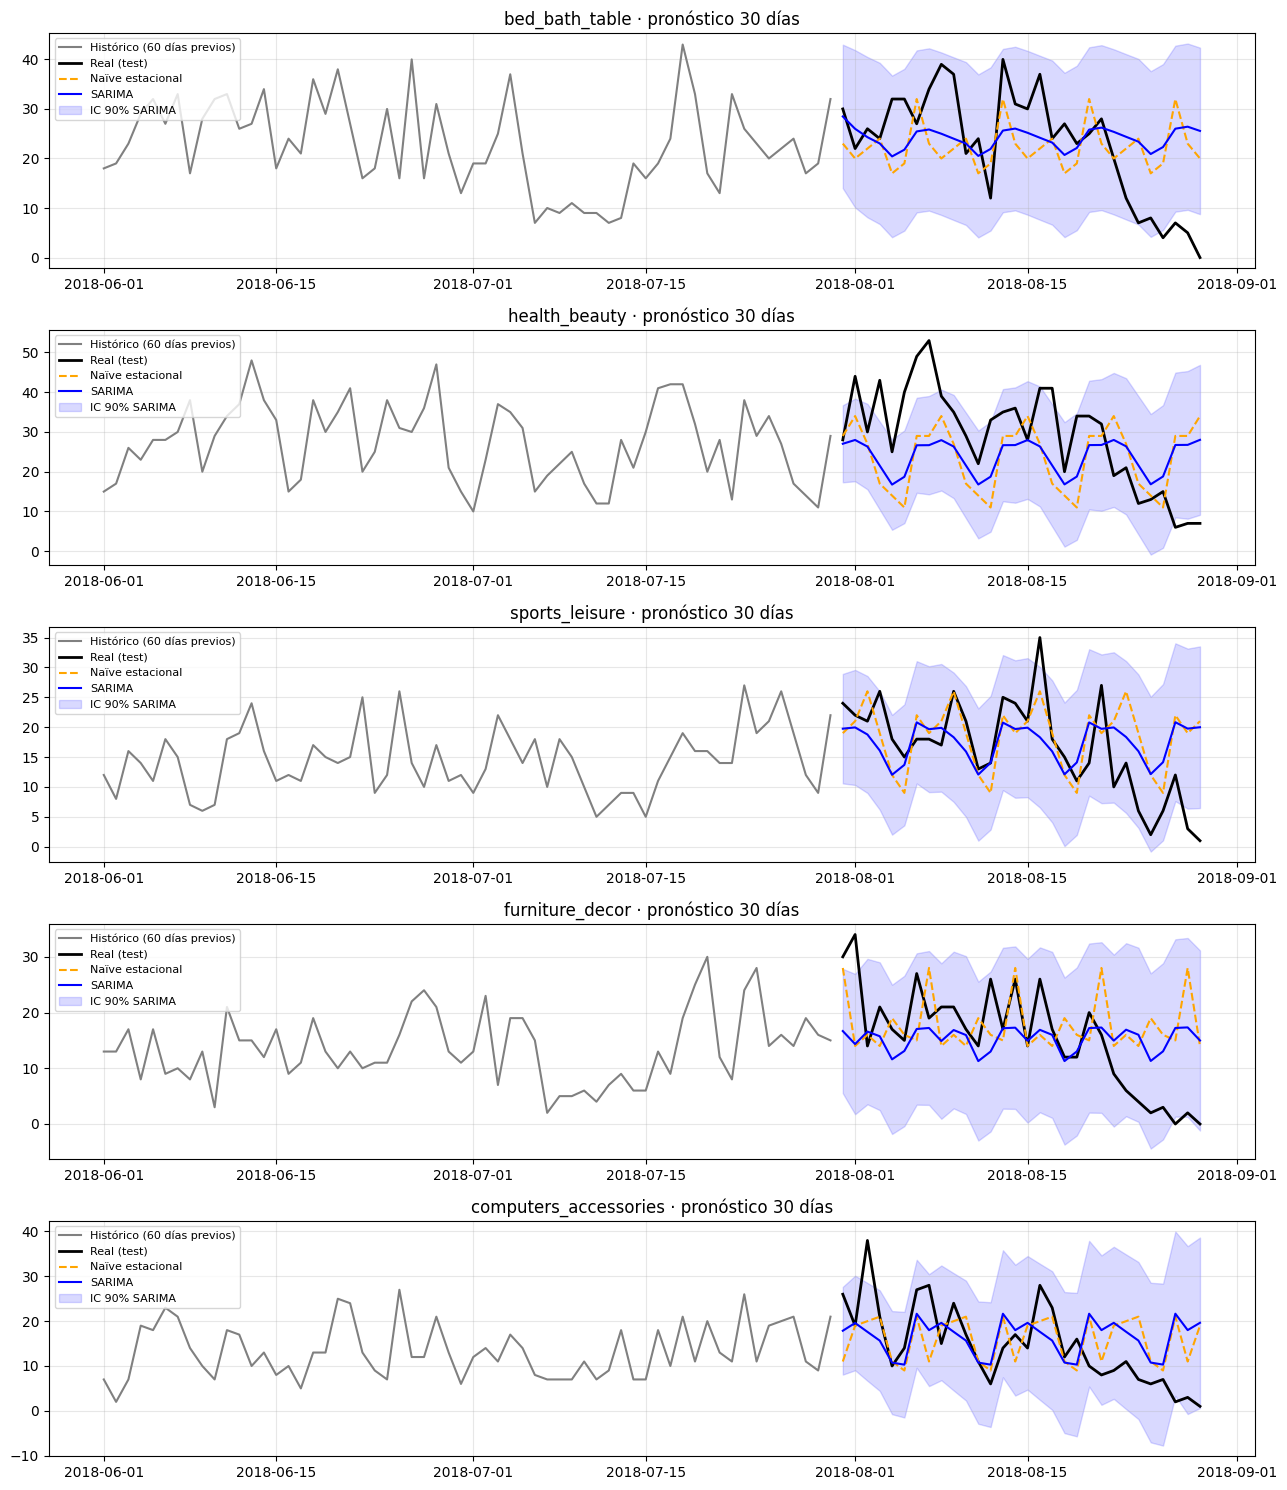

In [8]:
fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 3 * len(top_cats)))
for ax, cat in zip(axes, top_cats):
    if cat not in predicciones:
        continue
    test, pred_naive, pred_sarima, ci = predicciones[cat]
    contexto = series[cat].iloc[-90:-HORIZONTE]
    
    ax.plot(contexto.index, contexto.values, color='gray',
            label='Histórico (60 días previos)')
    ax.plot(test.index, test.values, color='black', lw=2, label='Real (test)')
    ax.plot(test.index, pred_naive, color='orange', ls='--',
            label='Naïve estacional')
    ax.plot(test.index, pred_sarima, color='blue', label='SARIMA')
    ax.fill_between(test.index, ci[:, 0], ci[:, 1], color='blue', alpha=0.15,
                    label='IC 90% SARIMA')
    ax.set_title(f'{cat} · pronóstico 30 días')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sistema de alertas tempranas

Convertimos el pronóstico en señales operativas para los planeadores de inventario.

- **Banda histórica:** P10 / P90 calculados sobre los últimos 90 días.
- **Alerta de stockout (rojo):** si el límite superior del pronóstico (IC 90 %) supera el P90 histórico → la demanda esperada puede agotar el stock objetivo.
- **Alerta de sobre-stock (amarillo):** si el límite inferior cae por debajo del P10 histórico → el stock objetivo va a quedar inflado.
- **Operación normal (verde):** dentro de la banda.

In [9]:
def generar_alertas(serie_hist, fechas_pronostico, ci, ventana_hist=90):
    p10 = serie_hist.iloc[-ventana_hist:].quantile(0.10)
    p90 = serie_hist.iloc[-ventana_hist:].quantile(0.90)
    media = serie_hist.iloc[-ventana_hist:].mean()
    alertas = []
    for fecha, lim_inf, lim_sup in zip(fechas_pronostico, ci[:, 0], ci[:, 1]):
        if lim_sup > p90:
            tipo = 'STOCKOUT'
            mensaje = (
                f'Demanda esperada hasta {lim_sup:.0f} items '
                f'(P90 histórico: {p90:.0f}). Reabastecer +{((lim_sup-media)/media*100):.0f}% '
                'sobre el pedido base.'
            )
        elif lim_inf < p10:
            tipo = 'SOBRE-STOCK'
            mensaje = (
                f'Demanda esperada baja hasta {lim_inf:.0f} items '
                f'(P10 histórico: {p10:.0f}). Considerar promoción / reducir reabasto.'
            )
        else:
            tipo = 'OK'
            mensaje = 'Demanda dentro de bandas históricas.'
        alertas.append({'fecha': fecha, 'tipo': tipo, 'mensaje': mensaje,
                        'lim_inf': lim_inf, 'lim_sup': lim_sup,
                        'p10_hist': p10, 'p90_hist': p90})
    return pd.DataFrame(alertas)

alertas_por_cat = {}
for cat in top_cats:
    if cat not in modelos_fit:
        continue
    fitted = modelos_fit[cat]
    fc = fitted.get_forecast(steps=14)  # próximos 14 días
    pred = fc.predicted_mean
    ci = fc.conf_int(alpha=0.10).values
    alertas_por_cat[cat] = generar_alertas(series[cat], pred.index, ci)

In [10]:
# Resumen ejecutivo: cuántas alertas y de qué tipo
resumen_alertas = pd.DataFrame([
    {
        'categoria': cat,
        'dias_pronosticados': len(df),
        'STOCKOUT': (df['tipo'] == 'STOCKOUT').sum(),
        'SOBRE-STOCK': (df['tipo'] == 'SOBRE-STOCK').sum(),
        'OK': (df['tipo'] == 'OK').sum(),
    }
    for cat, df in alertas_por_cat.items()
])
resumen_alertas

,categoria,dias_pronosticados,STOCKOUT,SOBRE-STOCK,OK
0,bed_bath_table,14,14,0,0
1,health_beauty,14,0,7,7
2,sports_leisure,14,11,3,0
3,furniture_decor,14,14,0,0
4,computers_accessories,14,12,2,0


In [11]:
# Detalle de las alertas críticas (no-OK)
alertas_consolidadas = pd.concat(
    [df.assign(categoria=cat) for cat, df in alertas_por_cat.items()],
    ignore_index=True
)
alertas_consolidadas[alertas_consolidadas['tipo'] != 'OK'][
    ['categoria', 'fecha', 'tipo', 'mensaje']
]

,categoria,fecha,tipo,mensaje
0,bed_bath_table,2018-07-31,STOCKOUT,Demanda esperada hasta 43 items (P90 histórico...
1,bed_bath_table,2018-08-01,STOCKOUT,Demanda esperada hasta 42 items (P90 histórico...
2,bed_bath_table,2018-08-02,STOCKOUT,Demanda esperada hasta 40 items (P90 histórico...
3,bed_bath_table,2018-08-03,STOCKOUT,Demanda esperada hasta 39 items (P90 histórico...
4,bed_bath_table,2018-08-04,STOCKOUT,Demanda esperada hasta 37 items (P90 histórico...
...,...,...,...,...
65,computers_accessories,2018-08-09,STOCKOUT,Demanda esperada hasta 31 items (P90 histórico...
66,computers_accessories,2018-08-10,STOCKOUT,Demanda esperada hasta 29 items (P90 histórico...
67,computers_accessories,2018-08-11,STOCKOUT,Demanda esperada hasta 24 items (P90 histórico...
68,computers_accessories,2018-08-12,STOCKOUT,Demanda esperada hasta 24 items (P90 histórico...


## 7. Visualización del sistema de alertas

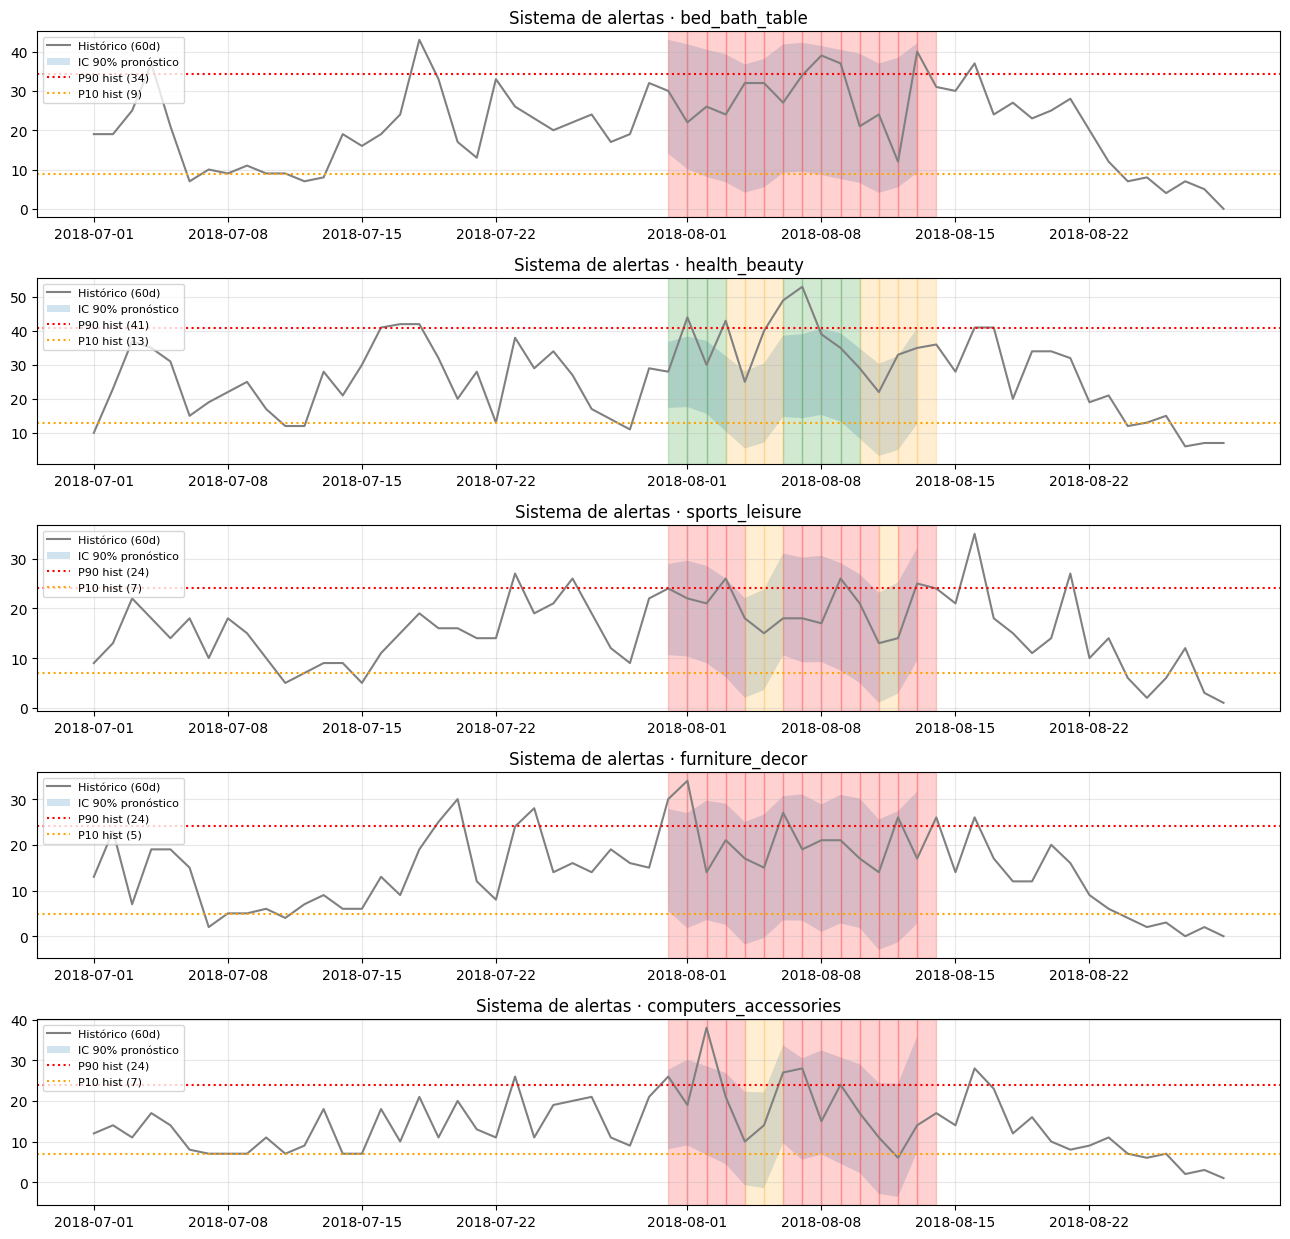

In [12]:
color_map = {'OK': 'green', 'STOCKOUT': 'red', 'SOBRE-STOCK': 'orange'}

fig, axes = plt.subplots(len(top_cats), 1, figsize=(13, 2.5 * len(top_cats)))
for ax, cat in zip(axes, top_cats):
    if cat not in modelos_fit:
        continue
    contexto = series[cat].iloc[-60:]
    df_alertas = alertas_por_cat[cat]
    ax.plot(contexto.index, contexto.values, color='gray',
            label='Histórico (60d)')
    ax.fill_between(df_alertas['fecha'], df_alertas['lim_inf'],
                    df_alertas['lim_sup'], alpha=0.2, label='IC 90% pronóstico')
    for _, r in df_alertas.iterrows():
        ax.axvspan(r['fecha'], r['fecha'] + pd.Timedelta(days=1),
                   color=color_map[r['tipo']], alpha=0.18)
    ax.axhline(df_alertas['p90_hist'].iloc[0], color='red', ls=':',
               label=f"P90 hist ({df_alertas['p90_hist'].iloc[0]:.0f})")
    ax.axhline(df_alertas['p10_hist'].iloc[0], color='orange', ls=':',
               label=f"P10 hist ({df_alertas['p10_hist'].iloc[0]:.0f})")
    ax.set_title(f'Sistema de alertas · {cat}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Persistencia

Guardamos:
- `series_demanda_diaria.csv` — panel diario por categoría (insumo del dashboard).
- `pronosticos_demanda.csv` — pronósticos a 14 días con bandas de alerta.
- `alertas_inventario.csv` — alertas accionables clasificadas (rojo / amarillo / verde).

In [13]:
# Panel diario
panel_export = pd.DataFrame(series).reset_index().rename(columns={'index': 'fecha'})
panel_export.to_csv('series_demanda_diaria.csv', index=False)

# Pronósticos consolidados
alertas_consolidadas.to_csv('alertas_inventario.csv', index=False)

# Tabla de métricas
tabla_resultados.to_csv('metricas_series_tiempo.csv', index=False)

print('Archivos generados:')
print(' · series_demanda_diaria.csv', panel_export.shape)
print(' · alertas_inventario.csv', alertas_consolidadas.shape)
print(' · metricas_series_tiempo.csv', tabla_resultados.shape)

Archivos generados:
 · series_demanda_diaria.csv (725, 6)
 · alertas_inventario.csv (70, 8)
 · metricas_series_tiempo.csv (10, 5)


## 9. Conclusiones

1. **Cumple el requisito de modelado de series de tiempo** del enunciado, con SARIMA(1,1,1)(1,1,1,7) entrenado por categoría sobre 700 días y evaluado sobre los últimos 30 días con métricas formales (MAE, RMSE, sMAPE).
2. **Cierra el ciclo con un sistema de alertas tempranas** (rojo/amarillo/verde) basado en bandas de probabilidad y percentiles históricos, exactamente lo solicitado: *“sistema de alertas tempranas que anticipe posibles quiebres de inventario o excesos de almacenamiento”*.
3. **Limitaciones honestas:** Olist es un marketplace, no inventario real. La traducción 1:1 a stockout debe interpretarse como *demanda esperada vs capacidad histórica*, no como rotación de almacén física. La estacionalidad anual no se modela porque sólo hay 2 años; un dataset productivo de 3+ años permitiría SARIMA(p,d,q)(P,D,Q,365).
4. **Lo que sigue:** los pronósticos se pueden integrar al modelo supervisado v2 como variable predictora (`demanda_esperada_proxima_semana`) y al dashboard como tarjetas de alerta accionable.